In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:

# 1. Define the Softmax function
def softmax(x):
    # Subtracting the max handles numerical stability (prevents overflow)
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)


In [103]:
raw_vectors = np.array([
    [ 0, 0 , 4],
    [ 0, 4,  0],
    [ 4, 0,  0],
    [ 2, 0,  2],
    [ 0, 2,  2],
    [ 2, 2,  0],
    [1,0,3],
    [3,0,1],
    [1,3,0],
    [0,1,3],
    [3,1,0],
    [0,3,1],
    [1.5,0,2.5],
    [2.5,0,1.5],
    [0,1.5,2.5],
    [0,2.5,1.5],
    [1.5,2.5,0],
    [2.5,1.5,0],

    
])

# 3. Apply Softmax to get probability distributions
softmax_vectors = softmax(raw_vectors)


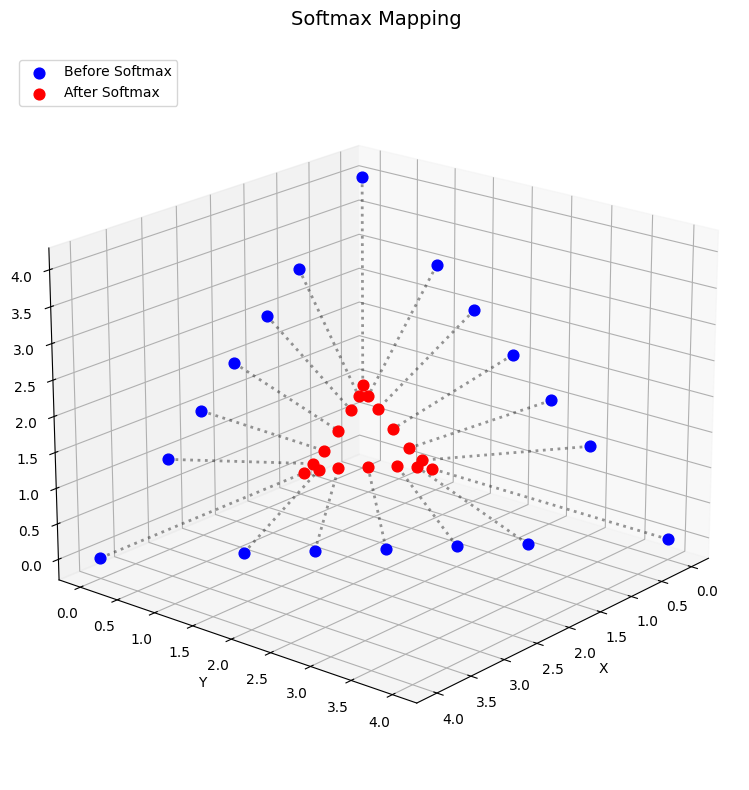

In [106]:
# Set up the single 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Softmax Mapping", fontsize=14, pad=20)

# --- 1. Plot Before Softmax (Blue) ---
ax.scatter(raw_vectors[:, 0], raw_vectors[:, 1], raw_vectors[:, 2], 
           color='blue', s=60, depthshade=False, label='Before Softmax')

# --- 2. Plot After Softmax (Red) ---
ax.scatter(softmax_vectors[:, 0], softmax_vectors[:, 1], softmax_vectors[:, 2], 
           color='red', s=60, depthshade=False, label='After Softmax')

# --- 3. Connect them with lines ---
for i in range(len(raw_vectors)):
    ax.plot(
        [raw_vectors[i, 0], softmax_vectors[i, 0]],
        [raw_vectors[i, 1], softmax_vectors[i, 1]],
        [raw_vectors[i, 2], softmax_vectors[i, 2]],
        color='black', linestyle=':', alpha=0.4, lw=2
    )

# --- 4. Draw the Simplex Triangle ---
# simplex = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0]])
# ax.plot(simplex[:, 0], simplex[:, 1], simplex[:, 2], color='gray', linestyle='--', lw=1.5, label='Simplex')

# Set standard angle view and legend
ax.view_init(elev=20, azim=40)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── paths ──────────────────────────────────────────────────────────
ROOT = pathlib.Path("/home/erfan/erfansoheil.github.io/writing-notes/temperature")
ASSETS = ROOT / "assets"
IMAGES = ASSETS / "images"
ASSETS.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)

# ── fixed setup from your article ──────────────────────────────────
V = np.array([2.5, 1.0, -0.5], dtype=float)
LABELS = ["P₁", "P₂", "P₃"]

TEMPS_ARGMAX = [2.0, 1.0, 0.5, 0.1, 0.05, 0.01]
TEMPS_UNIFORM = [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]


def softmax_temp(v, T):
    x = v / T
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()


def probs_for_temps(v, temps):
    return np.array([softmax_temp(v, T) for T in temps])


def simplex_boundary():
    return np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0]])


def barycentric_to_xy(p):
    """Map (p1,p2,p3) to 2D equilateral triangle."""
    p1, p2, p3 = p
    x = p2 + 0.5 * p3
    y = (np.sqrt(3) / 2) * p3
    return x, y


# ── 2D step snapshots ──────────────────────────────────────────────
def draw_simplex_panel(ax, p, title, highlight=(1, 0, 0)):
    tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], color="gray", lw=1.5)

    # vertex labels
    ax.text(-0.06, -0.04, "P₁=1", fontsize=9)
    ax.text(1.02, -0.04, "P₂=1", fontsize=9)
    ax.text(0.46, np.sqrt(3) / 2 + 0.03, "P₃=1", fontsize=9)

    x, y = barycentric_to_xy(p)
    ax.scatter([x], [y], s=80, c=[highlight], zorder=3, edgecolors="black", linewidths=0.6)

    ax.text(
        0.02, 0.95,
        f"{title}\n({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.12, np.sqrt(3) / 2 + 0.12)


def save_2d_steps(name, temps, cmap_name="viridis_r"):
    probs = probs_for_temps(V, temps)
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i / max(len(temps) - 1, 1)) for i in range(len(temps))]

    ncols = 3
    nrows = int(np.ceil(len(temps) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, T, p, color in zip(axes, temps, probs, colors):
        draw_simplex_panel(ax, p, f"T = {T:g}", highlight=color)

    for ax in axes[len(temps):]:
        ax.axis("off")

    fig.suptitle(name.replace("_", " ").title(), fontsize=13, y=1.02)
    fig.tight_layout()

    out = IMAGES / f"{name}_steps.png"
    fig.savefig(out, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("wrote", out)


# ── 3D Plotly (line + milestones + slider) ───────────────────────
def build_3d_figure(temps_milestones, dense_count=80, mode="argmax"):
    if mode == "argmax":
        T_dense = np.geomspace(temps_milestones[0], temps_milestones[-1], dense_count)
        colorscale = "Viridis_r"
    else:
        T_dense = np.geomspace(temps_milestones[0], temps_milestones[-1], dense_count)
        colorscale = "Viridis"

    P_dense = probs_for_temps(V, T_dense)
    P_mile = probs_for_temps(V, temps_milestones)

    boundary = simplex_boundary()
    fig = go.Figure()

    # simplex outline
    fig.add_trace(go.Scatter3d(
        x=boundary[:, 0], y=boundary[:, 1], z=boundary[:, 2],
        mode="lines",
        line=dict(color="gray", width=4),
        name="Simplex",
        hoverinfo="skip",
    ))

    # smooth path
    fig.add_trace(go.Scatter3d(
        x=P_dense[:, 0], y=P_dense[:, 1], z=P_dense[:, 2],
        mode="lines",
        line=dict(color="lightgray", width=3),
        name="Path",
        hoverinfo="skip",
    ))

    # milestone markers
    fig.add_trace(go.Scatter3d(
        x=P_mile[:, 0], y=P_mile[:, 1], z=P_mile[:, 2],
        mode="markers+text",
        marker=dict(size=7, color=temps_milestones, colorscale=colorscale, showscale=True,
                    colorbar=dict(title="T")),
        text=[f"T={T:g}" for T in temps_milestones],
        textposition="top center",
        name="Steps",
        hovertemplate="T=%{marker.color}<br>P=(%{x:.3f}, %{y:.3f}, %{z:.3f})<extra></extra>",
    ))

    # target point
    if mode == "argmax":
        target = np.array([1.0, 0.0, 0.0])
        target_name = "Argmax"
    else:
        target = np.array([1/3, 1/3, 1/3])
        target_name = "Uniform"

    fig.add_trace(go.Scatter3d(
        x=[target[0]], y=[target[1]], z=[target[2]],
        mode="markers+text",
        marker=dict(size=5, color="black", symbol="diamond"),
        text=[target_name],
        textposition="bottom center",
        name=target_name,
        hoverinfo="skip",
    ))

    # slider frames: one milestone at a time highlighted
    frames = []
    for i, T in enumerate(temps_milestones):
        p = P_mile[i]
        frames.append(go.Frame(
            name=f"T={T:g}",
            data=[
                go.Scatter3d(x=boundary[:, 0], y=boundary[:, 1], z=boundary[:, 2]),
                go.Scatter3d(x=P_dense[:, 0], y=P_dense[:, 1], z=P_dense[:, 2]),
                go.Scatter3d(
                    x=P_mile[:, 0], y=P_mile[:, 1], z=P_mile[:, 2],
                    mode="markers+text",
                    marker=dict(
                        size=[12 if j == i else 6 for j in range(len(temps_milestones))],
                        color=temps_milestones,
                        colorscale=colorscale,
                        showscale=True,
                        colorbar=dict(title="T"),
                    ),
                    text=[f"T={t:g}" for t in temps_milestones],
                    textposition="top center",
                ),
                go.Scatter3d(x=[target[0]], y=[target[1]], z=[target[2]]),
            ],
        ))

    fig.frames = frames

    fig.update_layout(
        title=f"Temperature → {'Argmax' if mode == 'argmax' else 'Uniform'} (v = {V.tolist()})",
        scene=dict(
            xaxis_title="P₁", yaxis_title="P₂", zaxis_title="P₃",
            aspectmode="cube",
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.2)),
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        height=500,
        updatemenus=[{
            "type": "buttons",
            "showactive": False,
            "x": 0.05, "y": 0.05,
            "buttons": [
                {"label": "Play", "method": "animate",
                 "args": [None, {"frame": {"duration": 700, "redraw": True}, "fromcurrent": True}]},
                {"label": "Pause", "method": "animate",
                 "args": [[None], {"frame": {"duration": 0}, "mode": "immediate"}]},
            ],
        }],
        sliders=[{
            "active": 0,
            "x": 0.1, "len": 0.85,
            "currentvalue": {"prefix": "Step: "},
            "steps": [
                {"label": f"T={T:g}", "method": "animate", "args": [[f"T={T:g}"],
                 {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}]}
                for T in temps_milestones
            ],
        }],
    )

    return fig


def save_3d_html(filename, temps, mode):
    fig = build_3d_figure(temps, mode=mode)
    out = ASSETS / filename
    fig.write_html(out, include_plotlyjs="cdn", config={"displayModeBar": True})
    print("wrote", out)


if __name__ == "__main__":
    save_2d_steps("argmax_simplex", TEMPS_ARGMAX, cmap_name="viridis_r")
    save_2d_steps("uniform_simplex", TEMPS_UNIFORM, cmap_name="viridis")

    save_3d_html("argmax_3d.html", TEMPS_ARGMAX, mode="argmax")
    save_3d_html("uniform_3d.html", TEMPS_UNIFORM, mode="uniform")

TypeError: unsupported operand type(s) for /: 'str' and 'str'